In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.metrics import confusion_matrix, classification_report

# Carga de archivos
train_df = pd.read_csv('train.csv')
X = train_df.drop('class', axis=1)
y = train_df['class']

print(f"Dataset cargado: {X.shape[1]} características y {X.shape[0]} muestras.")

Dataset cargado: 609 características y 1000 muestras.


NB con 10 variables - Accuracy CV: 0.6380
NB con 20 variables - Accuracy CV: 0.6260
NB con 30 variables - Accuracy CV: 0.6300
NB con 40 variables - Accuracy CV: 0.6050
NB con 51 variables - Accuracy CV: 0.6030


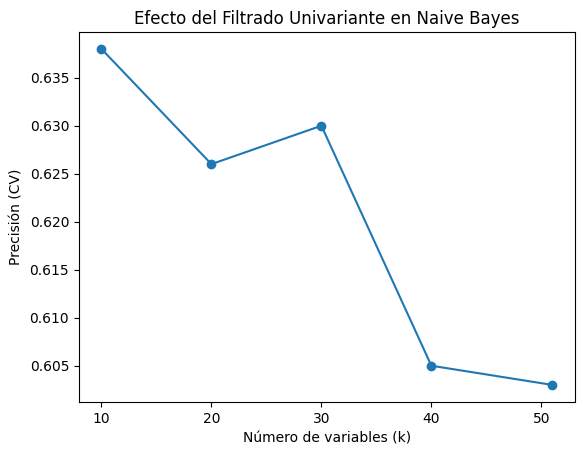

In [2]:
# Probamos Naive Bayes con diferentes números de características (K)
results_nb = []
k_values = [10, 20, 30, 40, 51]

for k in k_values:
    nb_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=k)),
        ('classifier', GaussianNB())
    ])
    
    cv_scores = cross_val_score(nb_pipe, X, y, cv=5)
    results_nb.append(cv_scores.mean())
    print(f"NB con {k} variables - Accuracy CV: {cv_scores.mean():.4f}")

# Gráfica de codo para ver cuántas variables son óptimas
plt.plot(k_values, results_nb, marker='o')
plt.title('Efecto del Filtrado Univariante en Naive Bayes')
plt.xlabel('Número de variables (k)')
plt.ylabel('Precisión (CV)')
plt.show()

In [3]:
# NOTA: Este proceso puede tardar unos minutos porque entrena el modelo varias veces
rfe_selector = RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=30)
rfe_pipe = Pipeline([
    ('selector', rfe_selector),
    ('classifier', RandomForestClassifier(random_state=42))
])

rfe_scores = cross_val_score(rfe_pipe, X, y, cv=5)
print(f"RF con RFE (30 mejores variables) - Accuracy CV: {rfe_scores.mean():.4f}")

RF con RFE (30 mejores variables) - Accuracy CV: 0.8130


In [4]:
# Usaremos el Pipeline para asegurar que el proceso es limpio
final_rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [100, 300],
    'classifier__max_depth': [None, 12, 20],
    'classifier__min_samples_leaf': [1, 4],
    'classifier__max_features': ['sqrt', 0.5] # Probar con el 50% de las variables
}

grid_search = GridSearchCV(final_rf_pipe, param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X, y)

print(f"Mejor configuración encontrada: {grid_search.best_params_}")
print(f"Mejor Accuracy 5-fold CV: {grid_search.best_score_:.4f}")

Mejor configuración encontrada: {'classifier__max_depth': 12, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
Mejor Accuracy 5-fold CV: 0.8320


In [5]:
# Resumen de resultados (ejemplo para vuestro PDF)
data = {
    "Classifier": ["Gaussian Naive Bayes", "Random Forest Classifier"],
    "Best parameters": ["Default + StandardScaler", str(grid_search.best_params_)],
    "Train accuracy": [
        accuracy_score(y, nb_pipe.fit(X, y).predict(X)), # Necesitarías haber definido nb_pipe arriba
        accuracy_score(y, grid_search.predict(X))
    ],
    "5-fold CV accuracy": [max(results_nb), grid_search.best_score_]
}
summary_table = pd.DataFrame(data)
print(summary_table)

NameError: name 'accuracy_score' is not defined